# Executive Sales Dashboard — Superstore Analysis
### Portfolio 1 · Data Cleaning + Exploratory Data Analysis

**Tujuan proyek:** menyiapkan data penjualan Superstore yang bersih dan menghasilkan
analisis yang dapat dipakai CEO / Sales Director untuk memonitor performa penjualan.

**Alur notebook:**
1. Load data mentah
2. Data Cleaning (duplikat, missing value, format tanggal, format currency, konsistensi nama produk)
3. Exploratory Data Analysis (KPI, tren bulanan, region, kategori, top customer & product)
4. Ekspor data bersih untuk dashboard

**Dataset:** Sample Superstore (4 tahun, retail US — Furniture, Office Supplies, Technology).


## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df_raw = pd.read_csv("data/superstore_raw.csv")
print("Dimensi data mentah:", df_raw.shape)
df_raw.head()

Dimensi data mentah: (10800, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"42,420.00",South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2.00,0.00,41.91
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"42,420.00",South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.00,0.00,219.58
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,"90,036.00",West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.00,0.00,6.87
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,"33,311.00",South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5.00,0.45,-383.03
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,"33,311.00",South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2.00,0.20,2.52


In [2]:
# Ringkasan struktur & tipe data
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  str    
 1   Order ID       10800 non-null  str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       99

## 2. Data Cleaning

Pemeriksaan awal menemukan beberapa masalah kualitas data yang harus diperbaiki sebelum analisis:
- **Baris duplikat**
- **Baris tidak valid** (record sampah tanpa data order)
- **Format tanggal** masih berupa teks
- **Format currency / numerik** (profit punya desimal panjang)
- **Konsistensi penamaan produk** (spasi berlebih)


In [3]:
# --- Diagnosa kualitas data ---
print("Jumlah duplikat penuh :", df_raw.duplicated().sum())
print("\nMissing value per kolom (yang ada saja):")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

Jumlah duplikat penuh : 504

Missing value per kolom (yang ada saja):
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64


In [4]:
# Lihat contoh baris bermasalah: record dengan Order Date kosong
df_raw[df_raw["Order Date"].isnull()].head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9994,Person,Region,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9995,Anna Andreadi,West,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9996,Chuck Magee,East,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


> **Temuan:** baris dengan `Order Date` kosong ternyata adalah **record sampah** —
> kolom `Row ID` malah berisi nama orang dan `Order ID` berisi nama region, sementara
> seluruh kolom transaksi (Sales, Profit, dst.) kosong. Baris seperti ini bukan order
> nyata dan harus dibuang.

In [5]:
df = df_raw.copy()
n0 = len(df)

# 2.1 Hapus duplikat
df = df.drop_duplicates()
n1 = len(df)
print(f"Hapus duplikat : {n0:,} -> {n1:,}  (terbuang {n0-n1:,})")

# 2.2 Hapus baris tidak valid (tanpa data order)
df = df[df["Order Date"].notnull()].copy()
n2 = len(df)
print(f"Hapus invalid  : {n1:,} -> {n2:,}  (terbuang {n1-n2:,})")

Hapus duplikat : 10,800 -> 10,296  (terbuang 504)
Hapus invalid  : 10,296 -> 9,994  (terbuang 302)


In [6]:
# 2.3 Format tanggal: teks -> datetime
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  format="%m/%d/%Y")
print("Rentang tanggal order:", df["Order Date"].min().date(), "s/d", df["Order Date"].max().date())

Rentang tanggal order: 2015-01-03 s/d 2018-12-30


In [7]:
# 2.4 Format currency / numerik
df["Sales"]    = df["Sales"].round(2)
df["Profit"]   = df["Profit"].round(2)
df["Discount"] = df["Discount"].round(2)
df["Quantity"] = df["Quantity"].astype(int)

# 2.5 Konsistensi penamaan (trim spasi, rapatkan spasi ganda)
text_cols = ["Product Name", "Category", "Sub-Category", "Region", "Segment", "Customer Name"]
for c in text_cols:
    df[c] = df[c].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)

# 2.6 Postal Code: Vermont diketahui kosong di dataset asli -> isi & standarkan 5 digit
df.loc[(df["State"] == "Vermont") & (df["Postal Code"].isnull()), "Postal Code"] = 5401
df["Postal Code"] = df["Postal Code"].astype(int).astype(str).str.zfill(5)

print("Sisa missing value:", int(df.isnull().sum().sum()))

Sisa missing value: 0


In [8]:
# 2.7 Feature engineering untuk analisis
df["Order Month"]   = df["Order Date"].dt.to_period("M").astype(str)
df["Order Year"]    = df["Order Date"].dt.year
df["Profit Margin"] = np.where(df["Sales"] > 0, df["Profit"] / df["Sales"], 0)

df = df.sort_values("Order Date").reset_index(drop=True)
print("Data bersih akhir:", df.shape)
df.head()

Data bersih akhir: (9994, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Profit Margin
0,7981,CA-2015-103800,2015-01-03,2015-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.45,2,0.20,5.55,2015-01,2015,0.34
1,740,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Labels,Avery 508,11.78,3,0.20,4.27,2015-01,2015,0.36
2,741,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.74,3,0.20,-64.77,2015-01,2015,-0.24
3,742,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.54,2,0.80,-5.49,2015-01,2015,-1.55
4,1760,CA-2015-141817,2015-01-05,2015-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.54,3,0.20,4.88,2015-01,2015,0.25


**Ringkasan cleaning:** `10.800 -> 10.296` (hapus 504 duplikat) `-> 9.994` (hapus 302 baris invalid).
Data akhir **9.994 record bersih**, tanpa missing value, tipe data benar.

## 3. Exploratory Data Analysis

### 3.1 KPI Utama

In [9]:
total_sales  = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
margin       = total_profit / total_sales * 100
aov          = df.groupby("Order ID")["Sales"].sum().mean()

print(f"Total Sales        : ${total_sales:,.0f}")
print(f"Total Profit       : ${total_profit:,.0f}")
print(f"Total Orders       : {total_orders:,}")
print(f"Profit Margin      : {margin:.2f}%")
print(f"Avg Order Value    : ${aov:,.2f}")

Total Sales        : $2,297,201
Total Profit       : $286,397
Total Orders       : 5,009
Profit Margin      : 12.47%
Avg Order Value    : $458.61


### 3.2 Tren Penjualan Bulanan

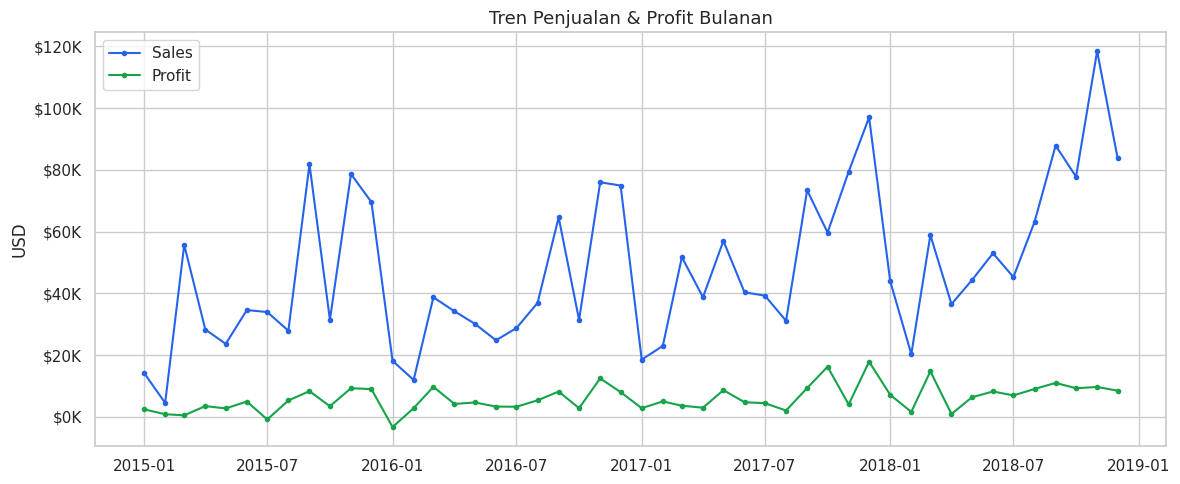

In [10]:
monthly = df.groupby("Order Month").agg(Sales=("Sales","sum"), Profit=("Profit","sum")).reset_index()
monthly["Order Month"] = pd.to_datetime(monthly["Order Month"])

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(monthly["Order Month"], monthly["Sales"], marker="o", ms=3, label="Sales", color="#2563eb")
ax.plot(monthly["Order Month"], monthly["Profit"], marker="o", ms=3, label="Profit", color="#16a34a")
ax.set_title("Tren Penjualan & Profit Bulanan")
ax.set_ylabel("USD"); ax.legend()
ax.yaxis.set_major_formatter(lambda x,_: f"${x/1000:.0f}K")
plt.tight_layout(); plt.show()

> Penjualan menunjukkan **tren naik dari tahun ke tahun** dengan **puncak musiman tiap
> akhir tahun (Q4, Nov–Des)**. Profit mengikuti pola serupa namun jauh lebih tipis.

### 3.3 Sales & Profit per Region

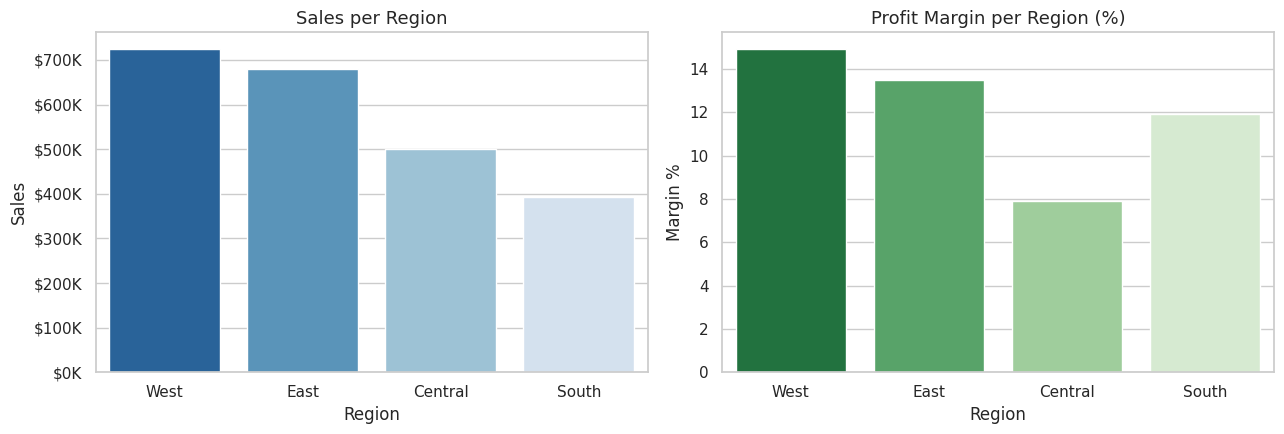

,Region,Sales,Profit,Margin %
3,West,"725,457.76","108,418.31",14.94
1,East,"678,781.30","91,522.50",13.48
0,Central,"501,239.76","39,706.24",7.92
2,South,"391,721.83","46,749.49",11.93


In [11]:
region = (df.groupby("Region")
            .agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
            .reset_index())
region["Margin %"] = region["Profit"] / region["Sales"] * 100
region = region.sort_values("Sales", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
sns.barplot(data=region, x="Region", y="Sales", ax=axes[0], palette="Blues_r", hue="Region", legend=False)
axes[0].set_title("Sales per Region"); axes[0].yaxis.set_major_formatter(lambda x,_: f"${x/1000:.0f}K")
sns.barplot(data=region, x="Region", y="Margin %", ax=axes[1], palette="Greens_r", hue="Region", legend=False)
axes[1].set_title("Profit Margin per Region (%)")
plt.tight_layout(); plt.show()
region

> **West & East** memimpin penjualan. Yang perlu diwaspadai: **Central** punya margin
> paling rendah — sinyal masalah profitabilitas, bukan volume.

### 3.4 Sales & Profit per Category

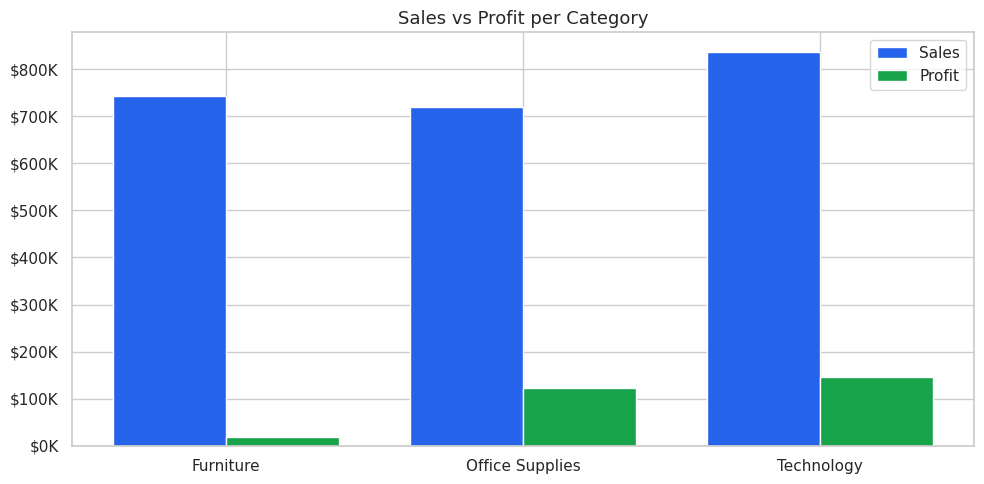

,Category,Sales,Profit,Margin %
0,Furniture,"741,999.73","18,451.10",2.49
1,Office Supplies,"719,046.90","122,490.00",17.04
2,Technology,"836,154.02","145,455.44",17.40


In [12]:
cat = (df.groupby("Category")
         .agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
         .reset_index())
cat["Margin %"] = cat["Profit"] / cat["Sales"] * 100

fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(cat)); w = 0.38
ax.bar(x-w/2, cat["Sales"],  w, label="Sales",  color="#2563eb")
ax.bar(x+w/2, cat["Profit"], w, label="Profit", color="#16a34a")
ax.set_xticks(x); ax.set_xticklabels(cat["Category"])
ax.set_title("Sales vs Profit per Category"); ax.legend()
ax.yaxis.set_major_formatter(lambda v,_: f"${v/1000:.0f}K")
plt.tight_layout(); plt.show()
cat

> **Technology** dan **Office Supplies** adalah mesin profit. **Furniture** menghasilkan
> sales besar tetapi profit sangat tipis — kandidat utama untuk diinvestigasi.

### 3.5 Hubungan Diskon vs Profit (per Sub-Category)

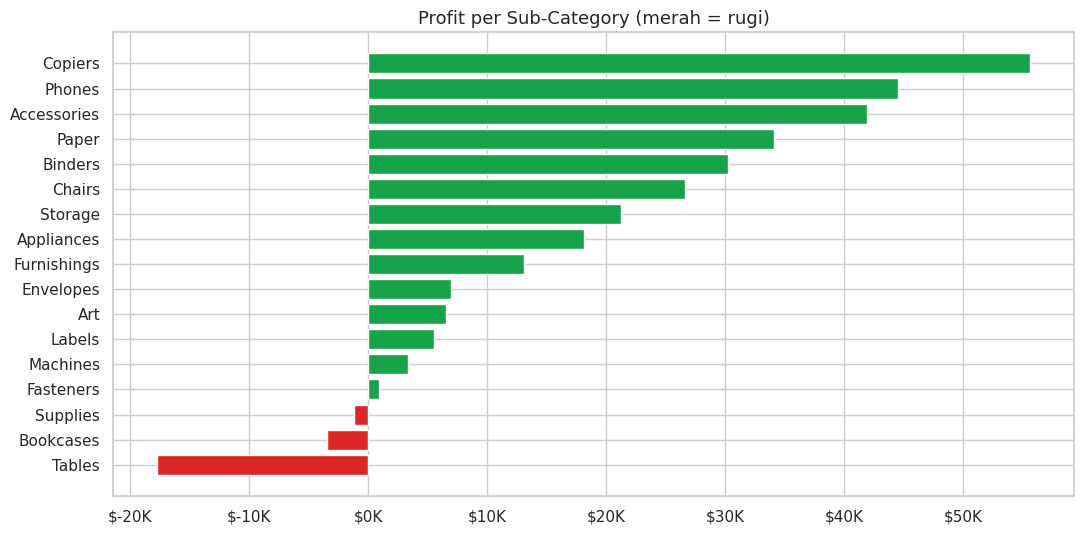

Sub-category PALING merugi:
Sub-Category      Sales     Profit  Discount  Margin %
      Tables 206,965.53 -17,725.57      0.26     -8.56
   Bookcases 114,879.98  -3,472.59      0.21     -3.02
    Supplies  46,673.52  -1,189.08      0.08     -2.55
   Fasteners   3,024.25     949.52      0.08     31.40
    Machines 189,238.60   3,384.72      0.31      1.79


In [13]:
sub = (df.groupby("Sub-Category")
         .agg(Sales=("Sales","sum"), Profit=("Profit","sum"), Discount=("Discount","mean"))
         .reset_index())
sub["Margin %"] = sub["Profit"]/sub["Sales"]*100

fig, ax = plt.subplots(figsize=(11,5.5))
colors = ["#dc2626" if p<0 else "#16a34a" for p in sub["Profit"]]
order = sub.sort_values("Profit")
ax.barh(order["Sub-Category"], order["Profit"], color=["#dc2626" if p<0 else "#16a34a" for p in order["Profit"]])
ax.set_title("Profit per Sub-Category (merah = rugi)")
ax.xaxis.set_major_formatter(lambda v,_: f"${v/1000:.0f}K")
plt.tight_layout(); plt.show()

print("Sub-category PALING merugi:")
print(order[["Sub-Category","Sales","Profit","Discount","Margin %"]].head(5).to_string(index=False))

> **Tables, Bookcases, dan Supplies merugi** meski penjualannya tidak kecil. Korelasinya
> kuat dengan **diskon tinggi** — diskon menggerus margin sampai negatif.

Korelasi Discount vs Profit (level transaksi): -0.219


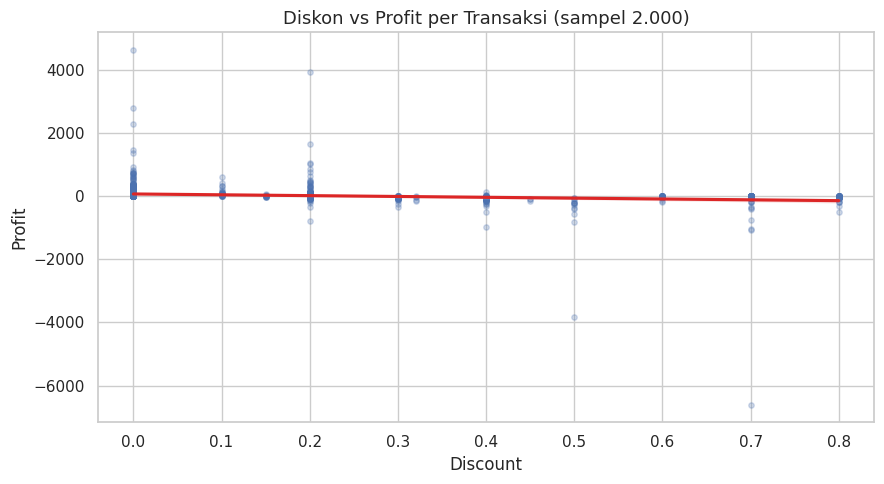

In [14]:
corr = df["Discount"].corr(df["Profit"])
print(f"Korelasi Discount vs Profit (level transaksi): {corr:.3f}")
fig, ax = plt.subplots(figsize=(9,5))
sns.regplot(data=df.sample(2000, random_state=1), x="Discount", y="Profit",
            scatter_kws=dict(alpha=0.25, s=15), line_kws=dict(color="#dc2626"), ax=ax)
ax.set_title("Diskon vs Profit per Transaksi (sampel 2.000)")
plt.tight_layout(); plt.show()

### 3.6 Top 10 Customer & Product

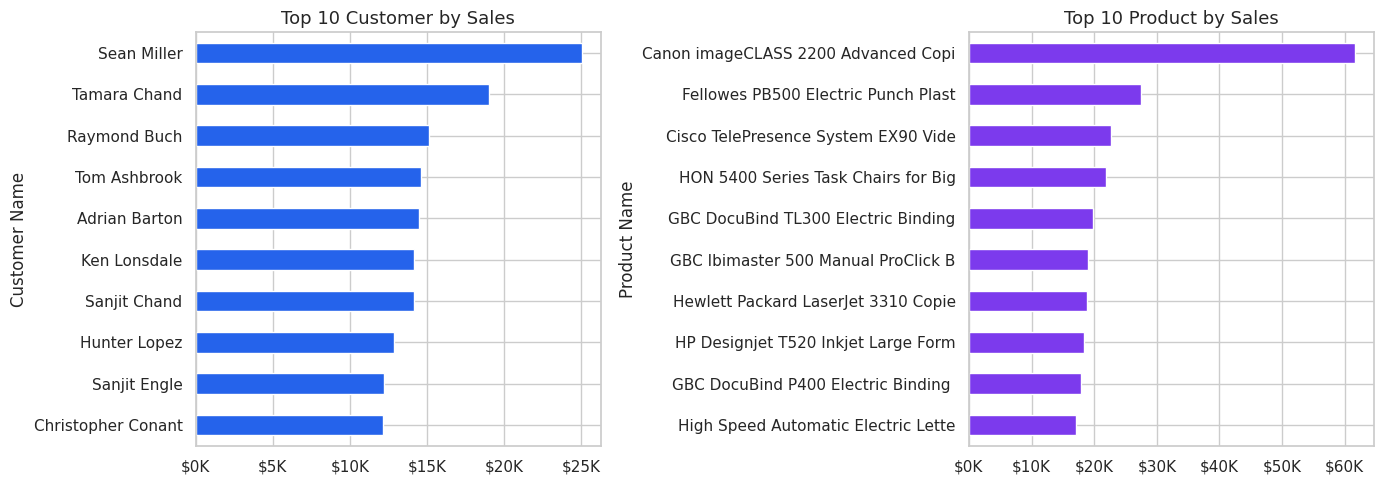

In [15]:
top_cust = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_prod = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1,2, figsize=(14,5))
top_cust.sort_values().plot.barh(ax=axes[0], color="#2563eb")
axes[0].set_title("Top 10 Customer by Sales"); axes[0].xaxis.set_major_formatter(lambda v,_:f"${v/1000:.0f}K")
top_prod.sort_values().plot.barh(ax=axes[1], color="#7c3aed")
axes[1].set_title("Top 10 Product by Sales"); axes[1].xaxis.set_major_formatter(lambda v,_:f"${v/1000:.0f}K")
axes[1].set_yticklabels([t.get_text()[:35] for t in axes[1].get_yticklabels()])
plt.tight_layout(); plt.show()

### 3.7 Penjualan per Segment Pelanggan

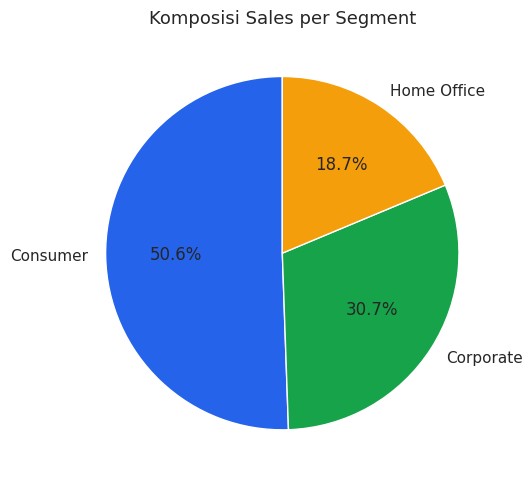

,Segment,Sales,Profit
0,Consumer,"1,161,401.12","134,118.64"
1,Corporate,"706,146.32","91,979.13"
2,Home Office,"429,653.21","60,298.77"


In [16]:
seg = df.groupby("Segment").agg(Sales=("Sales","sum"), Profit=("Profit","sum")).reset_index()
fig, ax = plt.subplots(figsize=(7,5))
ax.pie(seg["Sales"], labels=seg["Segment"], autopct="%1.1f%%",
       colors=["#2563eb","#16a34a","#f59e0b"], startangle=90)
ax.set_title("Komposisi Sales per Segment"); plt.tight_layout(); plt.show()
seg

## 4. Ekspor Data Bersih

In [17]:
df.to_csv("data/superstore_clean.csv", index=False)
print("Tersimpan: data/superstore_clean.csv", df.shape)

Tersimpan: data/superstore_clean.csv (9994, 24)


## 5. Ringkasan Temuan (Business Insight)

1. **Profitabilitas, bukan volume, adalah masalah utama.** Margin keseluruhan hanya **12,5%**.
2. **Furniture** (khususnya **Tables & Bookcases**) **merugi** akibat diskon agresif.
3. **Central** adalah region dengan margin terendah.
4. Penjualan **musiman** — puncak di Q4; momentum untuk perencanaan stok & kampanye.
5. Pendapatan **terkonsentrasi** pada sebagian kecil produk & customer (peluang loyalty).

> Rekomendasi lengkap & rencana aksi tersedia di file PDF **Executive Summary**.
